In [2]:
import sys

sys.path.append("..")

In [3]:
from plasma_separation.ion_trajectory import import_from_openmm_file
from plasma_separation.ion_collector import IonCollector, classification_loss
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

In [4]:
traj = import_from_openmm_file("ion_trajectories_openmm.h5")

In [5]:
traj.poses.shape

(500, 91, 3)

In [6]:
np.linalg.norm(traj.vels[:, 0], axis=-1)[:20]

array([2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507,
       2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507,
       2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507, 2988.9507,
       2988.9507, 2988.9507], dtype=float32)

IndexError: index 50 is out of bounds for axis 0 with size 50

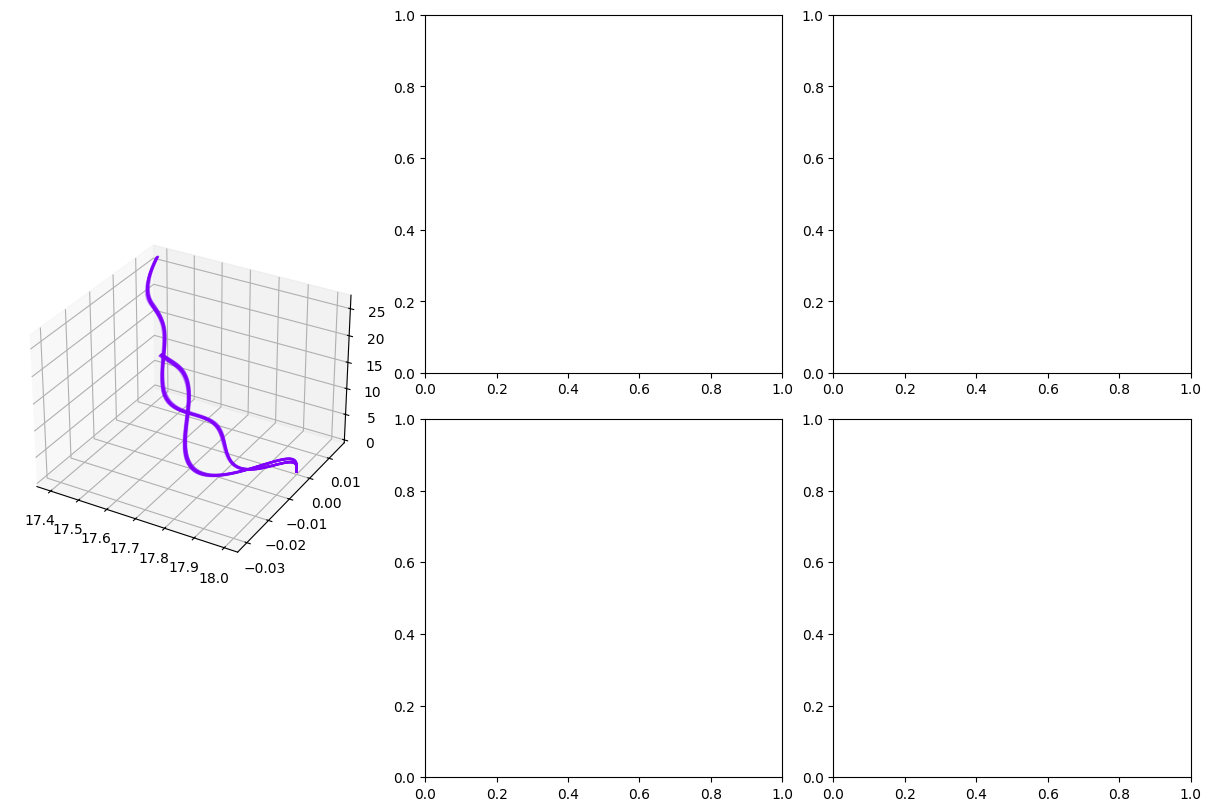

In [7]:
traj.poses = traj.poses[::10]
traj.plot_all().show()

(1, 100, 3)

In [8]:
collector = IonCollector(traj, 150, 25, np.deg2rad(70), 0, np.deg2rad(30))

C:\Users\vano2\AppData\Local\Temp\ipykernel_2896\1866653035.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  traj.plot_trajectories_xy(ax, get_cmap("rainbow"))


IndexError: index 50 is out of bounds for axis 0 with size 50

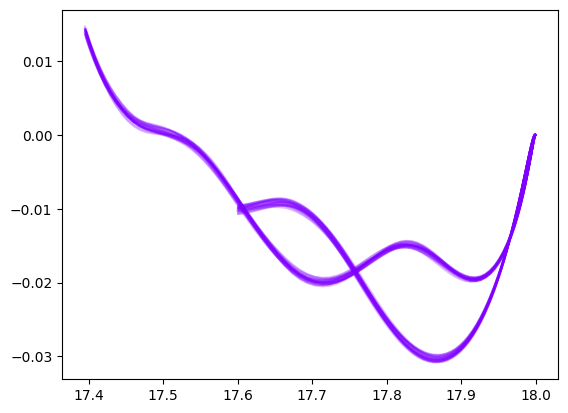

In [9]:
ax = plt.axes()
traj.plot_trajectories_xy(ax, get_cmap("rainbow"))
phi = np.linspace(collector.phi_min, 2 * np.pi, 100)
R = collector.R
ax.set_aspect("equal", adjustable="box")
ax.plot(R * np.cos(phi), R * np.sin(phi), color="black", ls="--")

C:\Users\vano2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\axes\_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
C:\Users\vano2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\axes\_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

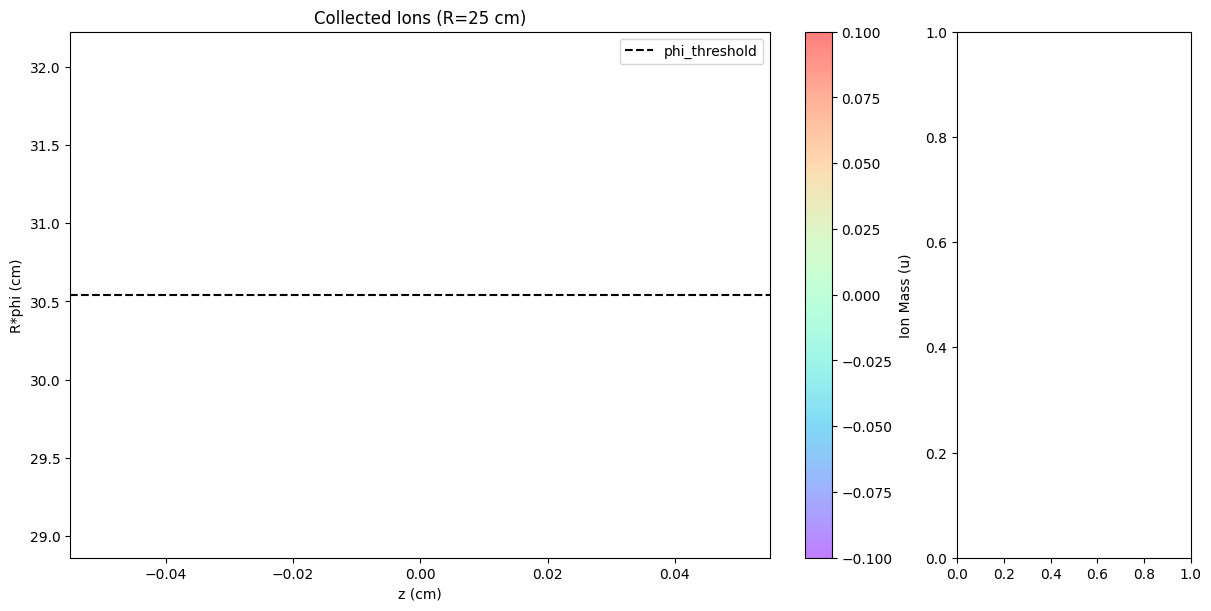

In [10]:
collector.plot_collected_ions().show()